**NHANES Cardiovascular Risk Analysis**

Lola Coker

In [ ]:
This project analyzes cardiovascular risk factors using NHANES data. The goal is to identify patterns in health indicators and explore predictive relationships using distributed data processing techniques.

Tools used include PySpark, Python, and data visualization libraries.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/NHANES Data Files for DSCI 632 Final Project/"

In [ ]:
import os
os.listdir(base_path)[:30]

['DEMO_L.xpt',
 'BPXO_L.xpt',
 'BMX_L.xpt',
 'PAQ_L.xpt',
 'SLQ_L.xpt',
 'SMQ_L.xpt',
 'MCQ_L.xpt',
 'DEMO_J.xpt',
 'BPX_J.xpt',
 'BPXO_J.xpt',
 'BMX_J.xpt',
 'MCQ_J.xpt',
 'PAQ_J.xpt',
 'SLQ_J.xpt',
 'SMQ_J.xpt',
 'DEMO_I.xpt',
 'BPX_I.xpt',
 'BMX_I.xpt',
 'MCQ_I.xpt',
 'PAQ_I.xpt',
 'SLQ_I.xpt',
 'SMQ_I.xpt',
 'Doc Files ']

In [ ]:
!pip install -q pyreadstat pyspark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.9 MB/s eta 0:00:00


In [ ]:
import os
import pyreadstat
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [ ]:
spark = SparkSession.builder \
    .appName("NHANES_Project") \
    .getOrCreate()

In [ ]:
def load_xpt_to_spark(path):
    pdf, meta = pyreadstat.read_xport(path, encoding="latin1")
    return spark.createDataFrame(pdf)

##Loading data files for all cycles

In [ ]:
#Load Cycle I (2015-2016)
demo_i = load_xpt_to_spark(base_path + "DEMO_I.xpt")
bmx_i  = load_xpt_to_spark(base_path + "BMX_I.xpt")
bpx_i  = load_xpt_to_spark(base_path + "BPX_I.xpt")
mcq_i  = load_xpt_to_spark(base_path + "MCQ_I.xpt")
paq_i  = load_xpt_to_spark(base_path + "PAQ_I.xpt")
slq_i  = load_xpt_to_spark(base_path + "SLQ_I.xpt")
smq_i  = load_xpt_to_spark(base_path + "SMQ_I.xpt")

print("Cycle I Loaded")



Cycle I Loaded


In [ ]:
#Load Cycle J (2017-2018)

demo_j = load_xpt_to_spark(base_path + "DEMO_J.xpt")
bmx_j  = load_xpt_to_spark(base_path + "BMX_J.xpt")
bpx_j  = load_xpt_to_spark(base_path + "BPX_J.xpt")
mcq_j  = load_xpt_to_spark(base_path + "MCQ_J.xpt")
paq_j  = load_xpt_to_spark(base_path + "PAQ_J.xpt")
slq_j  = load_xpt_to_spark(base_path + "SLQ_J.xpt")
smq_j  = load_xpt_to_spark(base_path + "SMQ_J.xpt")

print("Cycle J loaded")

Cycle J loaded


In [ ]:
#Load Cycle L (2021-2023)

demo_l = load_xpt_to_spark(base_path + "DEMO_L.xpt")
bmx_l  = load_xpt_to_spark(base_path + "BMX_L.xpt")
bpx_l  = load_xpt_to_spark(base_path + "BPXO_L.xpt")
mcq_l  = load_xpt_to_spark(base_path + "MCQ_L.xpt")
paq_l  = load_xpt_to_spark(base_path + "PAQ_L.xpt")
slq_l  = load_xpt_to_spark(base_path + "SLQ_L.xpt")
smq_l  = load_xpt_to_spark(base_path + "SMQ_L.xpt")

print("Cycle L loaded")

Cycle L loaded


##Cycle I

In [ ]:
#Selecting variables for Cycle I

#Demo Variables
demo_i_sel = demo_i.select(
    "SEQN",
    "RIDAGEYR",   # age
    "RIAGENDR",   # sex
    "RIDRETH3",   # race
    "INDFMPIR"    # income ratio
)

#Body Measures Variables
bmx_i_sel = bmx_i.select(
    "SEQN",
    "BMXBMI",
    "BMXWT",
    "BMXHT"
)

#Blood Pressure Variables
bpx_i_sel = bpx_i.select(
    "SEQN",
    "BPXSY1","BPXSY2","BPXSY3","BPXSY4",
    "BPXDI1","BPXDI2","BPXDI3","BPXDI4"
)

#Cardiavascular Disease Variables
mcq_i_sel = mcq_i.select(
    "SEQN",
    "MCQ160B",  # heart failure
    "MCQ160C",  # coronary heart disease
    "MCQ160D",  # angina
    "MCQ160E",  # heart attack
    "MCQ160F"   # stroke
)

#Physical Activity Variables
paq_i_sel = paq_i.select(
    "SEQN",
    "PAQ650",
    "PAQ665",
    "PAD680"
)

#Sleep Variables
slq_i_sel = slq_i.select(
    "SEQN",
    "SLD012"
)

#Smoking Variables
smq_i_sel = smq_i.select(
    "SEQN",
    "SMQ020",
    "SMQ040",
    "SMD641",
    "SMD650"
)

#Merging All tables
df_i = demo_i_sel \
    .join(bmx_i_sel, "SEQN", "left") \
    .join(bpx_i_sel, "SEQN", "left") \
    .join(mcq_i_sel, "SEQN", "left") \
    .join(paq_i_sel, "SEQN", "left") \
    .join(slq_i_sel, "SEQN", "left") \
    .join(smq_i_sel, "SEQN", "left") \
    .withColumn("cycle", F.lit("2015_2016"))

In [ ]:
#Sanity Check
df_i.printSchema()
df_i.show(5)

root
 |-- SEQN: double (nullable = true)
 |-- RIDAGEYR: double (nullable = true)
 |-- RIAGENDR: double (nullable = true)
 |-- RIDRETH3: double (nullable = true)
 |-- INDFMPIR: double (nullable = true)
 |-- BMXBMI: double (nullable = true)
 |-- BMXWT: double (nullable = true)
 |-- BMXHT: double (nullable = true)
 |-- BPXSY1: double (nullable = true)
 |-- BPXSY2: double (nullable = true)
 |-- BPXSY3: double (nullable = true)
 |-- BPXSY4: double (nullable = true)
 |-- BPXDI1: double (nullable = true)
 |-- BPXDI2: double (nullable = true)
 |-- BPXDI3: double (nullable = true)
 |-- BPXDI4: double (nullable = true)
 |-- MCQ160B: double (nullable = true)
 |-- MCQ160C: double (nullable = true)
 |-- MCQ160D: double (nullable = true)
 |-- MCQ160E: double (nullable = true)
 |-- MCQ160F: double (nullable = true)
 |-- PAQ650: double (nullable = true)
 |-- PAQ665: double (nullable = true)
 |-- PAD680: double (nullable = true)
 |-- SLD012: double (nullable = true)
 |-- SMQ020: double (nullable = true

In [ ]:
#Creating Avg BP for Cycle I
# Convert NaN BP values to null first
bp_cols_i = ["BPXSY1","BPXSY2","BPXSY3","BPXSY4","BPXDI1","BPXDI2","BPXDI3","BPXDI4"]

for c in bp_cols_i:
    df_i = df_i.withColumn(
        c,
        F.when(F.isnan(F.col(c)) | F.col(c).isNull(), None).otherwise(F.col(c))
    )

# Count valid systolic readings
df_i = df_i.withColumn(
    "sbp_n",
    F.when(F.col("BPXSY1").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXSY2").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXSY3").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXSY4").isNotNull(), 1).otherwise(0)
)

# Sum valid systolic readings
df_i = df_i.withColumn(
    "sbp_sum",
    F.coalesce(F.col("BPXSY1"), F.lit(0.0)) +
    F.coalesce(F.col("BPXSY2"), F.lit(0.0)) +
    F.coalesce(F.col("BPXSY3"), F.lit(0.0)) +
    F.coalesce(F.col("BPXSY4"), F.lit(0.0))
)

# Count valid diastolic readings
df_i = df_i.withColumn(
    "dbp_n",
    F.when(F.col("BPXDI1").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXDI2").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXDI3").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXDI4").isNotNull(), 1).otherwise(0)
)

# Sum valid diastolic readings
df_i = df_i.withColumn(
    "dbp_sum",
    F.coalesce(F.col("BPXDI1"), F.lit(0.0)) +
    F.coalesce(F.col("BPXDI2"), F.lit(0.0)) +
    F.coalesce(F.col("BPXDI3"), F.lit(0.0)) +
    F.coalesce(F.col("BPXDI4"), F.lit(0.0))
)

# Safe average calculation
df_i = df_i.withColumn(
    "avg_sbp",
    F.when(F.col("sbp_n") > 0, F.col("sbp_sum") / F.col("sbp_n")).otherwise(None)
)

df_i = df_i.withColumn(
    "avg_dbp",
    F.when(F.col("dbp_n") > 0, F.col("dbp_sum") / F.col("dbp_n")).otherwise(None)
)

#Creating Hypertension Variable for Cycle I
df_i = df_i.withColumn(
    "hypertension",
    F.when((F.col("avg_sbp") >= 130) | (F.col("avg_dbp") >= 80), 1).otherwise(0)
)

#Creating CVD Outcome for Cycle I
df_i = df_i.withColumn(
    "cvd",
    F.when(
        (F.col("MCQ160B") == 1) |
        (F.col("MCQ160C") == 1) |
        (F.col("MCQ160D") == 1) |
        (F.col("MCQ160E") == 1) |
        (F.col("MCQ160F") == 1),
        1
    ).otherwise(0)
)

#Adults only
df_i = df_i.filter(F.col("RIDAGEYR") >= 20)

In [ ]:
df_i.select(
    "BPXSY1","BPXSY2","BPXSY3","BPXSY4",
    "BPXDI1","BPXDI2","BPXDI3","BPXDI4",
    "avg_sbp","avg_dbp"
).show(10)

+------+------+------+------+------+------+------+------+------------------+------------------+
|BPXSY1|BPXSY2|BPXSY3|BPXSY4|BPXDI1|BPXDI2|BPXDI3|BPXDI4|           avg_sbp|           avg_dbp|
+------+------+------+------+------+------+------+------+------------------+------------------+
| 178.0| 180.0| 180.0|  NULL| 116.0| 114.0| 104.0|  NULL|179.33333333333334|111.33333333333333|
| 152.0| 148.0| 150.0|  NULL|  78.0|  70.0|  74.0|  NULL|             150.0|              74.0|
| 130.0| 138.0| 118.0|  NULL|  56.0|  44.0|  56.0|  NULL|128.66666666666666|              52.0|
| 154.0| 146.0| 146.0|  NULL|  84.0|  90.0|  94.0|  NULL|148.66666666666666| 89.33333333333333|
|  NULL|  NULL|  NULL|  NULL|  NULL|  NULL|  NULL|  NULL|              NULL|              NULL|
|  NULL| 164.0| 166.0| 166.0|  NULL|  78.0|  78.0|  76.0|165.33333333333334| 77.33333333333333|
| 128.0| 132.0| 128.0|  NULL|  68.0|  70.0|  74.0|  NULL|129.33333333333334| 70.66666666666667|
| 158.0| 156.0| 154.0|  NULL|  80.0|  84

In [ ]:
#Sanity check
df_i.groupBy("cvd").count().show()

+---+-----+
|cvd|count|
+---+-----+
|  1|  635|
|  0| 5084|
+---+-----+



##Cycle J

In [ ]:
# Selecting variables for Cycle J

# Demo Variables
demo_j_sel = demo_j.select(
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "INDFMPIR"
)

# Body Measures Variables
bmx_j_sel = bmx_j.select(
    "SEQN",
    "BMXBMI",
    "BMXWT",
    "BMXHT"
)

# Blood Pressure Variables
bpx_j_sel = bpx_j.select(
    "SEQN",
    "BPXSY1","BPXSY2","BPXSY3","BPXSY4",
    "BPXDI1","BPXDI2","BPXDI3","BPXDI4"
)

# Cardiovascular Disease Variables
mcq_j_sel = mcq_j.select(
    "SEQN",
    "MCQ160B",
    "MCQ160C",
    "MCQ160D",
    "MCQ160E",
    "MCQ160F"
)

# Physical Activity Variables
paq_j_sel = paq_j.select(
    "SEQN",
    "PAQ650",
    "PAQ665",
    "PAD680"
)

# Sleep Variables
slq_j_sel = slq_j.select(
    "SEQN",
    "SLD012"
)

# Smoking Variables
smq_j_sel = smq_j.select(
    "SEQN",
    "SMQ020",
    "SMQ040",
    "SMD641",
    "SMD650"
)

# Merging all tables
# Merging All Tables
df_j = demo_j_sel \
    .join(bmx_j_sel, "SEQN", "left") \
    .join(bpx_j_sel, "SEQN", "left") \
    .join(mcq_j_sel, "SEQN", "left") \
    .join(paq_j_sel, "SEQN", "left") \
    .join(slq_j_sel, "SEQN", "left") \
    .join(smq_j_sel, "SEQN", "left") \
    .withColumn("cycle", F.lit("2017_2018"))

In [ ]:
# Convert BP NaN values to null
bp_cols_j = ["BPXSY1","BPXSY2","BPXSY3","BPXSY4","BPXDI1","BPXDI2","BPXDI3","BPXDI4"]

for c in bp_cols_j:
    df_j = df_j.withColumn(
        c,
        F.when(F.isnan(F.col(c)) | F.col(c).isNull(), None).otherwise(F.col(c))
    )

    # Average Blood Pressure Variables

df_j = df_j.withColumn(
    "sbp_n",
    F.when(F.col("BPXSY1").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXSY2").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXSY3").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXSY4").isNotNull(), 1).otherwise(0)
)

df_j = df_j.withColumn(
    "sbp_sum",
    F.coalesce(F.col("BPXSY1"), F.lit(0.0)) +
    F.coalesce(F.col("BPXSY2"), F.lit(0.0)) +
    F.coalesce(F.col("BPXSY3"), F.lit(0.0)) +
    F.coalesce(F.col("BPXSY4"), F.lit(0.0))
)

df_j = df_j.withColumn(
    "dbp_n",
    F.when(F.col("BPXDI1").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXDI2").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXDI3").isNotNull(), 1).otherwise(0) +
    F.when(F.col("BPXDI4").isNotNull(), 1).otherwise(0)
)

df_j = df_j.withColumn(
    "dbp_sum",
    F.coalesce(F.col("BPXDI1"), F.lit(0.0)) +
    F.coalesce(F.col("BPXDI2"), F.lit(0.0)) +
    F.coalesce(F.col("BPXDI3"), F.lit(0.0)) +
    F.coalesce(F.col("BPXDI4"), F.lit(0.0))
)

df_j = df_j.withColumn(
    "avg_sbp",
    F.when(F.col("sbp_n") > 0, F.col("sbp_sum") / F.col("sbp_n")).otherwise(None)
)

df_j = df_j.withColumn(
    "avg_dbp",
    F.when(F.col("dbp_n") > 0, F.col("dbp_sum") / F.col("dbp_n")).otherwise(None)
)

# Hypertension Variable
df_j = df_j.withColumn(
    "hypertension",
    F.when((F.col("avg_sbp") >= 130) | (F.col("avg_dbp") >= 80), 1).otherwise(0)
)

# Cardiovascular Disease Outcome Variable
df_j = df_j.withColumn(
    "cvd",
    F.when(
        (F.col("MCQ160B") == 1) |
        (F.col("MCQ160C") == 1) |
        (F.col("MCQ160D") == 1) |
        (F.col("MCQ160E") == 1) |
        (F.col("MCQ160F") == 1),
        1
    ).otherwise(0)
)

# Adults Only
df_j = df_j.filter(F.col("RIDAGEYR") >= 20)

In [ ]:
#Sanity Check

df_j.select("SEQN", "avg_sbp", "avg_dbp", "hypertension", "cvd").show(10)
df_j.groupBy("hypertension").count().show()
df_j.groupBy("cvd").count().show()

+-------+------------------+------------------+------------+---+
|   SEQN|           avg_sbp|           avg_dbp|hypertension|cvd|
+-------+------------------+------------------+------------+---+
|94021.0|110.66666666666667|              78.0|           0|  0|
|94375.0|             128.0|              78.0|           0|  0|
|94381.0|127.33333333333333|55.333333333333336|           0|  0|
|94409.0|             102.0|              80.0|           1|  0|
|94698.0|142.66666666666666|              78.0|           1|  0|
|95135.0|             134.0| 68.66666666666667|           1|  1|
|95236.0|137.33333333333334|              64.0|           1|  0|
|95547.0|134.66666666666666| 72.66666666666667|           1|  0|
|95756.0|             126.0| 82.66666666666667|           1|  0|
|96143.0|174.66666666666666| 84.66666666666667|           1|  0|
+-------+------------------+------------------+------------+---+
only showing top 10 rows
+------------+-----+
|hypertension|count|
+------------+-----+
| 

##Cycle L

In [ ]:
# Selecting variables for Cycle L

# Selecting variables for Cycle L

# Demo Variables
demo_l_sel = demo_l.select(
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH3",
    "INDFMPIR"
)

# Body Measures Variables
bmx_l_sel = bmx_l.select(
    "SEQN",
    "BMXBMI",
    "BMXWT",
    "BMXHT"
)

# Blood Pressure Variables
bpx_l_sel = bpx_l.select(
    "SEQN",
    "BPXOSY1","BPXOSY2","BPXOSY3",
    "BPXODI1","BPXODI2","BPXODI3"
)

# Cardiovascular Disease Variables
mcq_l_sel = mcq_l.select(
    "SEQN",
    "MCQ160B",
    "MCQ160C",
    "MCQ160D",
    "MCQ160E",
    "MCQ160F"
)

# Physical Activity Variables
paq_l_sel = paq_l.select(
    "SEQN",
    F.col("PAD810Q").alias("PAQ650"),
    F.col("PAD790Q").alias("PAQ665"),
    "PAD680"
)

# Sleep Variables
slq_l_sel = slq_l.select(
    "SEQN",
    "SLD012"
)

# Smoking Variables
smq_l_sel = smq_l.select(
    "SEQN",
    "SMQ020",
    "SMQ040",
    "SMD641",
    "SMD650"
)

# Merging tables
df_l = demo_l_sel \
    .join(bmx_l_sel, "SEQN", "left") \
    .join(bpx_l_sel, "SEQN", "left") \
    .join(mcq_l_sel, "SEQN", "left") \
    .join(paq_l_sel, "SEQN", "left") \
    .join(slq_l_sel, "SEQN", "left") \
    .join(smq_l_sel, "SEQN", "left") \
    .withColumn("cycle", F.lit("2021_2023"))

In [ ]:
#Renaming BP columns to to keep everything Consistent
#Cycle L uses BPXO variable while the other 2 cycles used BPX

df_l = df_l.withColumnRenamed("BPXOSY1","BPXSY1") \
           .withColumnRenamed("BPXOSY2","BPXSY2") \
           .withColumnRenamed("BPXOSY3","BPXSY3") \
           .withColumnRenamed("BPXODI1","BPXDI1") \
           .withColumnRenamed("BPXODI2","BPXDI2") \
           .withColumnRenamed("BPXODI3","BPXDI3")

In [ ]:
#Converting NAN BP values to null
bp_cols_l = ["BPXSY1","BPXSY2","BPXSY3","BPXDI1","BPXDI2","BPXDI3"]

for c in bp_cols_l:
    df_l = df_l.withColumn(
        c,
        F.when(F.isnan(F.col(c)) | F.col(c).isNull(), None).otherwise(F.col(c))
    )

  #Creating AVG BP

df_l = df_l.withColumn(
    "sbp_n",
    F.when(F.col("BPXSY1").isNotNull(),1).otherwise(0) +
    F.when(F.col("BPXSY2").isNotNull(),1).otherwise(0) +
    F.when(F.col("BPXSY3").isNotNull(),1).otherwise(0)
)

df_l = df_l.withColumn(
    "dbp_n",
    F.when(F.col("BPXDI1").isNotNull(),1).otherwise(0) +
    F.when(F.col("BPXDI2").isNotNull(),1).otherwise(0) +
    F.when(F.col("BPXDI3").isNotNull(),1).otherwise(0)
)

df_l = df_l.withColumn(
    "sbp_sum",
    F.coalesce(F.col("BPXSY1"),F.lit(0)) +
    F.coalesce(F.col("BPXSY2"),F.lit(0)) +
    F.coalesce(F.col("BPXSY3"),F.lit(0))
)

df_l = df_l.withColumn(
    "dbp_sum",
    F.coalesce(F.col("BPXDI1"),F.lit(0)) +
    F.coalesce(F.col("BPXDI2"),F.lit(0)) +
    F.coalesce(F.col("BPXDI3"),F.lit(0))
)

df_l = df_l.withColumn(
    "avg_sbp",
    F.when(F.col("sbp_n") > 0, F.col("sbp_sum") / F.col("sbp_n")).otherwise(None)
)

df_l = df_l.withColumn(
    "avg_dbp",
    F.when(F.col("dbp_n") > 0, F.col("dbp_sum") / F.col("dbp_n")).otherwise(None)
)

#Hypertension variable
df_l = df_l.withColumn(
    "hypertension",
    F.when((F.col("avg_sbp") >= 130) | (F.col("avg_dbp") >= 80),1).otherwise(0)
)

#CVD Variable
df_l = df_l.withColumn(
    "cvd",
    F.when(
        (F.col("MCQ160B") == 1) |
        (F.col("MCQ160C") == 1) |
        (F.col("MCQ160D") == 1) |
        (F.col("MCQ160E") == 1) |
        (F.col("MCQ160F") == 1),
        1
    ).otherwise(0)
)

#Adults only
df_l = df_l.filter(F.col("RIDAGEYR") >= 20)

In [ ]:
#Cycle L only had 3 bp readings
# Adding missing BP columns so schemas match

df_l = df_l.withColumn("BPXSY4", F.lit(None).cast("double")) \
           .withColumn("BPXDI4", F.lit(None).cast("double"))

In [ ]:
#Sanity Check

df_l.select("SEQN","avg_sbp","avg_dbp","hypertension","cvd").show(10)

df_l.groupBy("hypertension").count().show()

df_l.groupBy("cvd").count().show()

+--------+------------------+------------------+------------+---+
|    SEQN|           avg_sbp|           avg_dbp|hypertension|cvd|
+--------+------------------+------------------+------------+---+
|130750.0|              NULL|              NULL|           0|  0|
|130842.0|             122.0|              83.0|           1|  0|
|130932.0|116.66666666666667| 81.66666666666667|           1|  0|
|131589.0|              NULL|              NULL|           0|  1|
|132180.0|              93.0|57.666666666666664|           0|  0|
|132741.0|             120.0| 68.33333333333333|           0|  0|
|132929.0|129.66666666666666| 69.33333333333333|           0|  1|
|132960.0|              NULL|              NULL|           0|  1|
|133347.0|              NULL|              NULL|           0|  1|
|133361.0|              99.0|62.666666666666664|           0|  0|
+--------+------------------+------------------+------------+---+
only showing top 10 rows
+------------+-----+
|hypertension|count|
+--------

##Merging all cycles

In [ ]:
nhanes_all = df_i.unionByName(df_j).unionByName(df_l)

In [ ]:
#Sanity Check

nhanes_all.groupBy("cycle").count().show()

+---------+-----+
|    cycle|count|
+---------+-----+
|2015_2016| 5719|
|2017_2018| 5569|
|2021_2023| 7809|
+---------+-----+



#Renaming Variables



In [ ]:
nhanes_all = nhanes_all \
    .withColumnRenamed("RIDAGEYR", "age") \
    .withColumnRenamed("RIAGENDR", "sex") \
    .withColumnRenamed("RIDRETH3", "race_ethnicity") \
    .withColumnRenamed("INDFMPIR", "income_ratio") \
    .withColumnRenamed("BMXBMI", "bmi") \
    .withColumnRenamed("BMXWT", "weight_kg") \
    .withColumnRenamed("BMXHT", "height_cm") \
    .withColumnRenamed("SLD012", "sleep_hours") \
    .withColumnRenamed("PAQ650", "vigorous_activity") \
    .withColumnRenamed("PAQ665", "moderate_activity") \
    .withColumnRenamed("PAD680", "sedentary_minutes") \
    .withColumnRenamed("SMQ020", "ever_smoked") \
    .withColumnRenamed("SMQ040", "current_smoker") \
    .withColumnRenamed("SMD641", "cigarettes_per_day") \
    .withColumnRenamed("SMD650", "years_smoking")


In [ ]:
nhanes_all.printSchema()

root
 |-- SEQN: double (nullable = true)
 |-- age: double (nullable = true)
 |-- sex: double (nullable = true)
 |-- race_ethnicity: double (nullable = true)
 |-- income_ratio: double (nullable = true)
 |-- bmi: double (nullable = true)
 |-- weight_kg: double (nullable = true)
 |-- height_cm: double (nullable = true)
 |-- BPXSY1: double (nullable = true)
 |-- BPXSY2: double (nullable = true)
 |-- BPXSY3: double (nullable = true)
 |-- BPXSY4: double (nullable = true)
 |-- BPXDI1: double (nullable = true)
 |-- BPXDI2: double (nullable = true)
 |-- BPXDI3: double (nullable = true)
 |-- BPXDI4: double (nullable = true)
 |-- MCQ160B: double (nullable = true)
 |-- MCQ160C: double (nullable = true)
 |-- MCQ160D: double (nullable = true)
 |-- MCQ160E: double (nullable = true)
 |-- MCQ160F: double (nullable = true)
 |-- vigorous_activity: double (nullable = true)
 |-- moderate_activity: double (nullable = true)
 |-- sedentary_minutes: double (nullable = true)
 |-- sleep_hours: double (nullable =

In [ ]:
#Dropping intermediate BP calculation Columns
nhanes_all = nhanes_all.drop(
    "sbp_n",
    "sbp_sum",
    "dbp_n",
    "dbp_sum"
)

In [ ]:
#Converting Categorical Data to readable categories
nhanes_all = nhanes_all.withColumn(
    "sex",
    F.when(F.col("sex") == 1, "Male")
     .when(F.col("sex") == 2, "Female")
)

nhanes_all = nhanes_all.withColumn(
    "race_ethnicity",
    F.when(F.col("race_ethnicity") == 1, "Mexican American")
     .when(F.col("race_ethnicity") == 2, "Other Hispanic")
     .when(F.col("race_ethnicity") == 3, "Non-Hispanic White")
     .when(F.col("race_ethnicity") == 4, "Non-Hispanic Black")
     .when(F.col("race_ethnicity") == 6, "Non-Hispanic Asian")
     .when(F.col("race_ethnicity") == 7, "Other Race")
)

In [ ]:
#Converting NAN to Null for numeric variables

numeric_cols = [
    "bmi",
    "avg_sbp",
    "avg_dbp",
    "sleep_hours",
    "vigorous_activity",
    "moderate_activity",
    "sedentary_minutes",
    "cigarettes_per_day",
    "years_smoking"
]

for c in numeric_cols:
    nhanes_all = nhanes_all.withColumn(
        c,
        F.when(F.isnan(F.col(c)) | F.col(c).isNull(), None).otherwise(F.col(c))
    )

In [ ]:
#Sanity Check

nhanes_all.select(
    "age",
    "sex",
    "race_ethnicity",
    "bmi",
    "avg_sbp",
    "avg_dbp",
    "hypertension",
    "cvd"
).show(10)

+----+------+------------------+----+------------------+------------------+------------+---+
| age|   sex|    race_ethnicity| bmi|           avg_sbp|           avg_dbp|hypertension|cvd|
+----+------+------------------+----+------------------+------------------+------------+---+
|56.0|  Male|Non-Hispanic Black|33.6|179.33333333333334|111.33333333333333|           1|  1|
|46.0|  Male|  Mexican American|26.8|             150.0|              74.0|           1|  0|
|75.0|  Male|  Mexican American|26.5|128.66666666666666|              52.0|           0|  0|
|75.0|Female|        Other Race|27.1|148.66666666666666| 89.33333333333333|           1|  0|
|80.0|  Male|  Mexican American|29.1|              NULL|              NULL|           0|  0|
|67.0|  Male|  Mexican American|23.4|165.33333333333334| 77.33333333333333|           1|  1|
|32.0|  Male|  Mexican American|31.0|129.33333333333334| 70.66666666666667|           0|  0|
|58.0|Female|Non-Hispanic Black|31.4|             156.0| 82.6666666666

## Exploratory Data Analysis

Hypertension Prevalence

In [ ]:
total_n = nhanes_all.count()

htn_table = nhanes_all.groupBy("hypertension").count() \
    .withColumn("percent", F.round(F.col("count")/F.lit(total_n)*100,2))

htn_table.show()

+------------+-----+-------+
|hypertension|count|percent|
+------------+-----+-------+
|           1| 6923|  36.25|
|           0|12174|  63.75|
+------------+-----+-------+



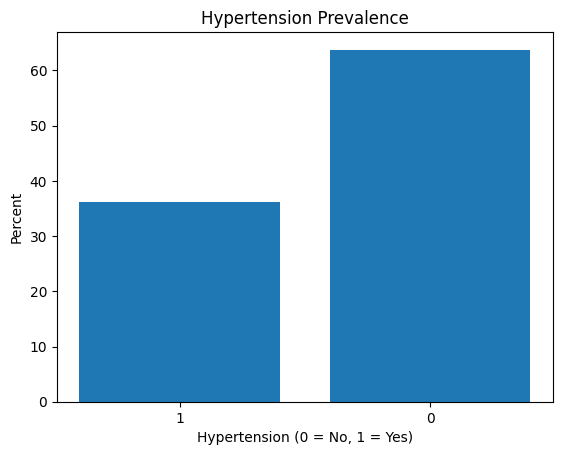

In [ ]:
import matplotlib.pyplot as plt

#plotting hypertension prevelance
htn_pd = htn_table.toPandas()

plt.bar(htn_pd["hypertension"].astype(str), htn_pd["percent"])
plt.title("Hypertension Prevalence")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Percent")
plt.show()

CVD Prevalence

In [ ]:
cvd_table = nhanes_all.groupBy("cvd").count() \
    .withColumn("percent", F.round(F.col("count")/F.lit(total_n)*100,2))

cvd_table.show()

+---+-----+-------+
|cvd|count|percent|
+---+-----+-------+
|  1| 2308|  12.09|
|  0|16789|  87.91|
+---+-----+-------+



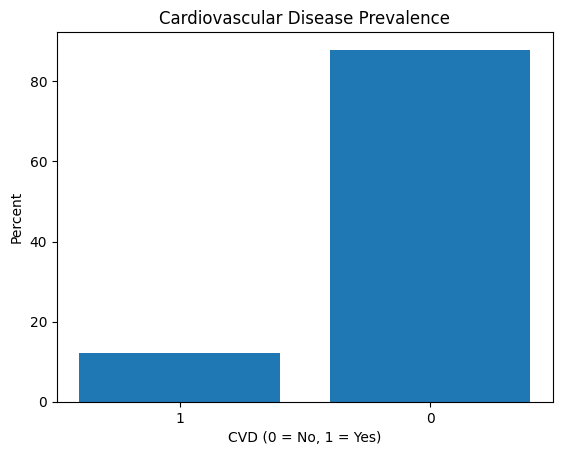

In [ ]:
#Plotting CVD Prevalence
cvd_pd = cvd_table.toPandas()

plt.bar(cvd_pd["cvd"].astype(str), cvd_pd["percent"])
plt.title("Cardiovascular Disease Prevalence")
plt.xlabel("CVD (0 = No, 1 = Yes)")
plt.ylabel("Percent")
plt.show()

Age Distribution

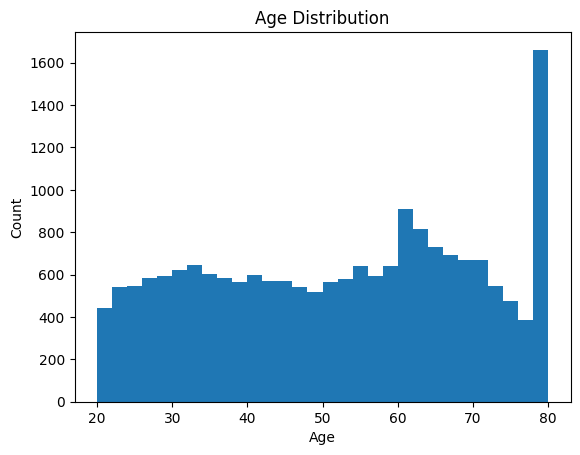

In [ ]:
age_pd = nhanes_all.select("age").toPandas()

plt.hist(age_pd["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

BMI vs Hypertension

In [ ]:
bmi_htn = nhanes_all.groupBy("hypertension").agg(
    F.round(F.mean("bmi"),2).alias("mean_bmi")
)

bmi_htn.show()

+------------+--------+
|hypertension|mean_bmi|
+------------+--------+
|           1|   30.77|
|           0|   29.02|
+------------+--------+



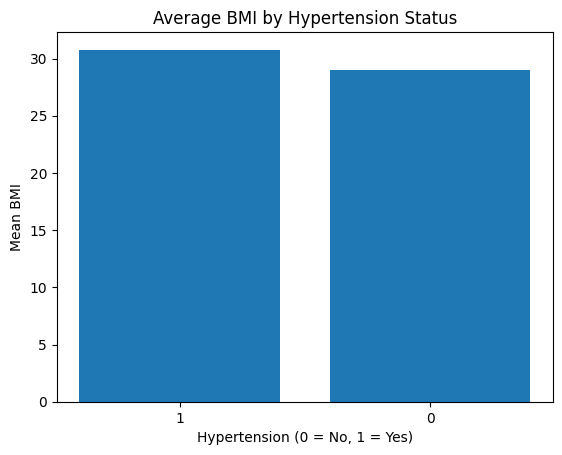

In [ ]:
#Plotting BMI vs Hypertension

bmi_pd = bmi_htn.toPandas()

plt.bar(bmi_pd["hypertension"].astype(str), bmi_pd["mean_bmi"])
plt.title("Average BMI by Hypertension Status")
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Mean BMI")
plt.show()

Age vs CVD

In [ ]:
age_cvd = nhanes_all.groupBy("cvd").agg(
    F.round(F.mean("age"),2).alias("mean_age")
)

age_cvd.show()

+---+--------+
|cvd|mean_age|
+---+--------+
|  1|   67.06|
|  0|   49.68|
+---+--------+



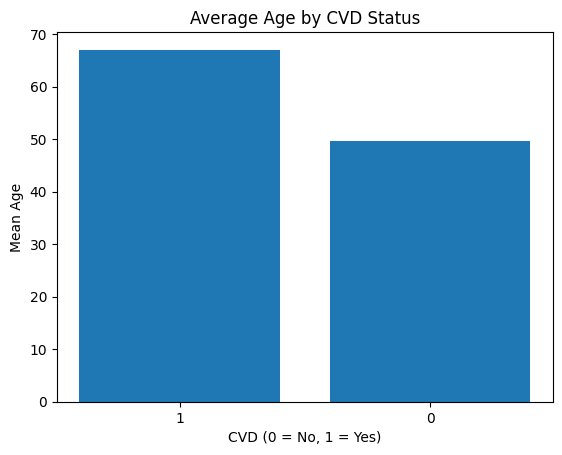

In [ ]:
#Plotting Age vs CVD

age_cvd_pd = age_cvd.toPandas()

plt.bar(age_cvd_pd["cvd"].astype(str), age_cvd_pd["mean_age"])
plt.title("Average Age by CVD Status")
plt.xlabel("CVD (0 = No, 1 = Yes)")
plt.ylabel("Mean Age")
plt.show()

Hypertension by Cycle

In [ ]:
cycle_htn = nhanes_all.groupBy("cycle","hypertension").count()

cycle_htn.show()

+---------+------------+-----+
|    cycle|hypertension|count|
+---------+------------+-----+
|2015_2016|           0| 3553|
|2015_2016|           1| 2166|
|2017_2018|           0| 3255|
|2017_2018|           1| 2314|
|2021_2023|           1| 2443|
|2021_2023|           0| 5366|
+---------+------------+-----+



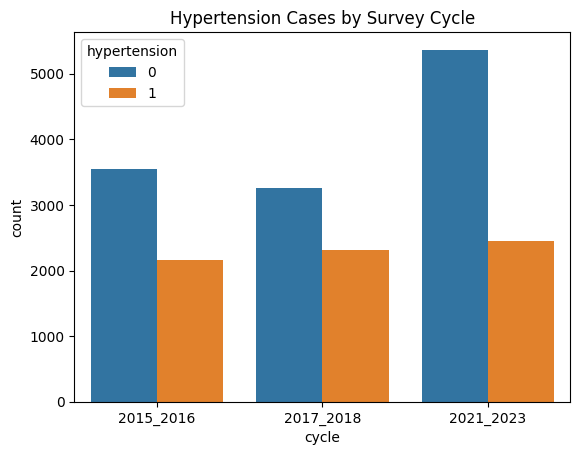

In [ ]:
#Plotting Hypertension by cycle
cycle_pd = cycle_htn.toPandas()

import seaborn as sns

sns.barplot(data=cycle_pd, x="cycle", y="count", hue="hypertension")
plt.title("Hypertension Cases by Survey Cycle")
plt.show()

In [ ]:
model_df = nhanes_all.select(
    "cvd",
    "age",
    "sex",
    "race_ethnicity",
    "income_ratio",
    "bmi",
    "avg_sbp",
    "avg_dbp",
    "hypertension",
    "ever_smoked",
    "current_smoker"
)

In [ ]:
model_df = model_df.dropna()
print("Rows after dropna:", model_df.count())

Rows after dropna: 5988


In [ ]:
model_df.groupBy("cvd").count().show()

+---+-----+
|cvd|count|
+---+-----+
|  1| 1044|
|  0| 4944|
+---+-----+



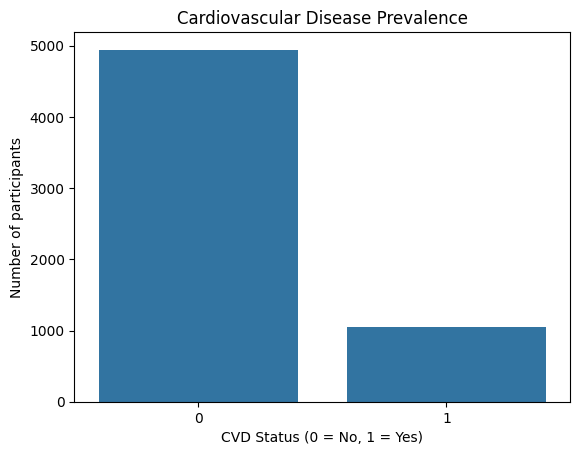

In [ ]:
cvd_counts = model_df.groupBy("cvd").count()

cvd_pd = cvd_counts.toPandas()

sns.barplot(data=cvd_pd, x="cvd", y="count")
plt.title("Cardiovascular Disease Prevalence")
plt.xlabel("CVD Status (0 = No, 1 = Yes)")
plt.ylabel("Number of participants")
plt.show()

In [ ]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

In [ ]:
#encoding categorical variables
sex_indexer = StringIndexer(
    inputCol="sex",
    outputCol="sex_index",
    handleInvalid="keep"
)

race_indexer = StringIndexer(
    inputCol="race_ethnicity",
    outputCol="race_index",
    handleInvalid="keep"
)

sex_encoder = OneHotEncoder(
    inputCol="sex_index",
    outputCol="sex_vec"
)

race_encoder = OneHotEncoder(
    inputCol="race_index",
    outputCol="race_vec"
)

In [ ]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "age",
    "income_ratio",
    "bmi",
    "avg_sbp",
    "avg_dbp",
    "hypertension",
    "ever_smoked",
    "current_smoker",
    "sex_vec",
    "race_vec"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

In [ ]:
train_df, test_df = model_df.randomSplit([0.7, 0.3], seed=42)

print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

Train rows: 4222
Test rows: 1766


Logistic Regression Model

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

In [ ]:
lr = LogisticRegression(
    labelCol="cvd",
    featuresCol="features",
    maxIter=20
)

In [ ]:
#Buildig Pipeline
lr_pipeline = Pipeline(stages=[
    sex_indexer,
    race_indexer,
    sex_encoder,
    race_encoder,
    assembler,
    lr
])

In [ ]:
#training model
lr_model = lr_pipeline.fit(train_df)

In [ ]:
#predictions

lr_preds = lr_model.transform(test_df)

In [ ]:
#Checking predictions
lr_preds.select("cvd","prediction","probability").show(10, truncate=False)

+---+----------+-----------------------------------------+
|cvd|prediction|probability                              |
+---+----------+-----------------------------------------+
|0  |0.0       |[0.9835437840188864,0.016456215981113576]|
|0  |0.0       |[0.9837042197598184,0.016295780240181634]|
|0  |0.0       |[0.9327552946977236,0.06724470530227644] |
|0  |0.0       |[0.9754417608608981,0.024558239139101934]|
|0  |0.0       |[0.9861652694734657,0.013834730526534278]|
|0  |0.0       |[0.9857332160507535,0.01426678394924652] |
|0  |0.0       |[0.9914106421757021,0.008589357824297927]|
|0  |0.0       |[0.9900375300706838,0.009962469929316153]|
|0  |0.0       |[0.9928531452483131,0.00714685475168686] |
|0  |0.0       |[0.9844411511017104,0.015558848898289623]|
+---+----------+-----------------------------------------+
only showing top 10 rows


In [ ]:
#Evaluating model

from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="cvd",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

lr_auc = evaluator.evaluate(lr_preds)

print("Logistic Regression AUC:", lr_auc)

Logistic Regression AUC: 0.7936520109066114


Random Forest

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="cvd",
    featuresCol="features",
    numTrees=100,
    seed=42
)

#pipeline

rf_pipeline = Pipeline(stages=[
    sex_indexer,
    race_indexer,
    sex_encoder,
    race_encoder,
    assembler,
    rf
])

#train

rf_model = rf_pipeline.fit(train_df)
rf_preds = rf_model.transform(test_df)

In [ ]:
#Evaluate

rf_auc = evaluator.evaluate(rf_preds)

print("Random Forest AUC:", rf_auc)

Random Forest AUC: 0.7757391785957737


Gradient Boosted Trees

In [ ]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    labelCol="cvd",
    featuresCol="features",
    maxIter=50,
    seed=42
)

gbt_pipeline = Pipeline(stages=[
    sex_indexer,
    race_indexer,
    sex_encoder,
    race_encoder,
    assembler,
    gbt
])

gbt_model = gbt_pipeline.fit(train_df)
gbt_preds = gbt_model.transform(test_df)

gbt_auc = evaluator.evaluate(gbt_preds)
print("GBT AUC:", gbt_auc)

GBT AUC: 0.7620196404226304


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosted Trees"],
    "AUC": [lr_auc, rf_auc, gbt_auc]
})

results = results.sort_values("AUC", ascending=False)
results

,Model,AUC
0,Logistic Regression,0.793652
1,Random Forest,0.775739
2,Gradient Boosted Trees,0.762020


Using Logistic Regression as the final model

In [ ]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

#set best model predictions
best_preds = lr_preds.withColumn(
    "risk_probability",
    vector_to_array("probability")[1]
)


best_preds.select("cvd", "prediction", "probability", "risk_probability").show(10, truncate=False)


+---+----------+-----------------------------------------+--------------------+
|cvd|prediction|probability                              |risk_probability    |
+---+----------+-----------------------------------------+--------------------+
|0  |0.0       |[0.9835437840188864,0.016456215981113576]|0.016456215981113576|
|0  |0.0       |[0.9837042197598184,0.016295780240181634]|0.016295780240181634|
|0  |0.0       |[0.9327552946977236,0.06724470530227644] |0.06724470530227644 |
|0  |0.0       |[0.9754417608608981,0.024558239139101934]|0.024558239139101934|
|0  |0.0       |[0.9861652694734657,0.013834730526534278]|0.013834730526534278|
|0  |0.0       |[0.9857332160507535,0.01426678394924652] |0.01426678394924652 |
|0  |0.0       |[0.9914106421757021,0.008589357824297927]|0.008589357824297927|
|0  |0.0       |[0.9900375300706838,0.009962469929316153]|0.009962469929316153|
|0  |0.0       |[0.9928531452483131,0.00714685475168686] |0.00714685475168686 |
|0  |0.0       |[0.9844411511017104,0.01

In [ ]:
#Creating Risk Levels
best_preds = best_preds.withColumn(
    "risk_level",
    F.when(F.col("risk_probability") < 0.20, "Low")
     .when((F.col("risk_probability") >= 0.20) & (F.col("risk_probability") < 0.50), "Moderate")
     .otherwise("High")
)

In [ ]:
#Recommendation layer
best_preds = best_preds.withColumn(
    "recommendation",
    F.when((F.col("current_smoker") == 1) & (F.col("risk_level") == "High"),
           "Smoking cessation and cardiovascular follow-up")
     .when((F.col("bmi") >= 30) & (F.col("risk_level").isin("Moderate", "High")),
           "Weight management and nutrition counseling")
     .when((F.col("hypertension") == 1) & (F.col("risk_level").isin("Moderate", "High")),
           "Blood pressure monitoring and lifestyle modification")
     .otherwise("Maintain healthy lifestyle")
)

In [ ]:
#Sanity check
best_preds.select(
    "cvd",
    "prediction",
    "risk_probability",
    "risk_level",
    "bmi",
    "hypertension",
    "current_smoker",
    "recommendation"
).show(15, truncate=False)

+---+----------+--------------------+----------+----+------------+--------------+--------------------------+
|cvd|prediction|risk_probability    |risk_level|bmi |hypertension|current_smoker|recommendation            |
+---+----------+--------------------+----------+----+------------+--------------+--------------------------+
|0  |0.0       |0.016456215981113576|Low       |33.2|0           |3.0           |Maintain healthy lifestyle|
|0  |0.0       |0.016295780240181634|Low       |23.0|0           |2.0           |Maintain healthy lifestyle|
|0  |0.0       |0.06724470530227644 |Low       |50.1|0           |2.0           |Maintain healthy lifestyle|
|0  |0.0       |0.024558239139101934|Low       |27.2|0           |1.0           |Maintain healthy lifestyle|
|0  |0.0       |0.013834730526534278|Low       |20.0|1           |3.0           |Maintain healthy lifestyle|
|0  |0.0       |0.01426678394924652 |Low       |34.7|0           |1.0           |Maintain healthy lifestyle|
|0  |0.0       |0.0

In [ ]:
best_preds.groupBy("risk_level").count().show()

best_preds.groupBy("recommendation").count().orderBy(F.desc("count")).show(truncate=False)

+----------+-----+
|risk_level|count|
+----------+-----+
|      High|   75|
|       Low| 1115|
|  Moderate|  576|
+----------+-----+

+----------------------------------------------------+-----+
|recommendation                                      |count|
+----------------------------------------------------+-----+
|Maintain healthy lifestyle                          |1278 |
|Weight management and nutrition counseling          |296  |
|Blood pressure monitoring and lifestyle modification|177  |
|Smoking cessation and cardiovascular follow-up      |15   |
+----------------------------------------------------+-----+

